--- Step 0: Generating Raw Data ---
Raw Dataset Preview:
        Age        Income     Score  Redundant_1  Gender  Customer_ID
0  1.689767 -40412.061474 -0.962936     1.163491  Female         1000
1  0.855820   8467.721602 -0.390659     0.435911    Male         1001
2 -1.175042 -42381.645570 -0.163790     0.508040    Male         1002
Initial Shape: (200, 6)

--- Step 1: Cleaning Data ---
Shape after removing Income outliers: (198, 6)

--- Step 2: Integrating Data ---
Shape after merging tables: (198, 7)

--- Step 3: Transforming Data ---
Transformed Dataset Preview (Encoded & Scaled):
        Age    Income     Score  Redundant_1  Customer_ID  Gender_Male  \
0  1.339907 -1.089964 -1.771565     1.163491         1000        False   
1  0.665761 -0.356703 -0.734593     0.435911         1001         True   
2 -0.975943 -1.119510 -0.323505     0.508040         1002         True   

   Loyalty_Member_Yes  
0               False  
1                True  
2                True   

--- Step 4: 

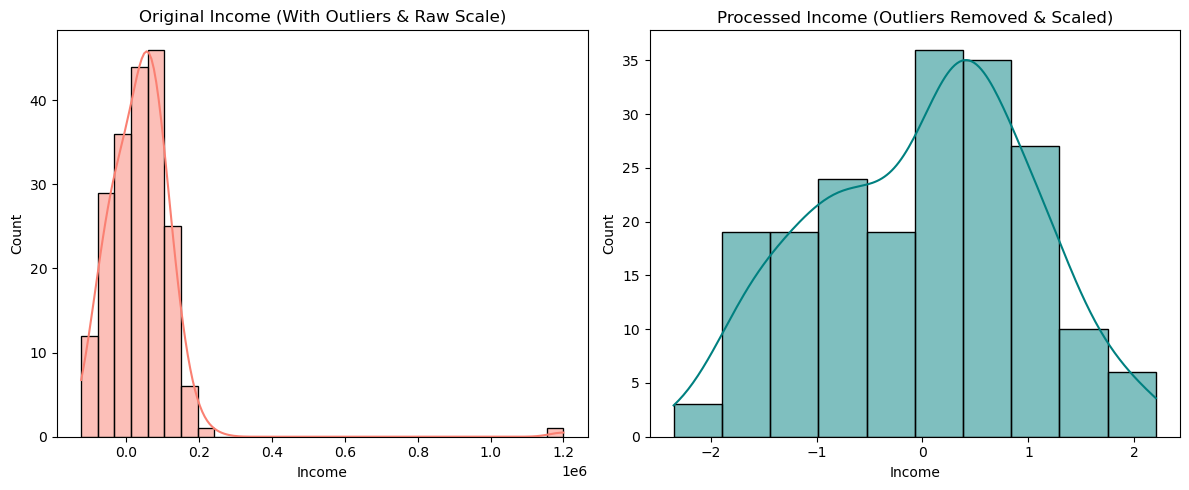

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler

# ==========================================
# 0. GENERATE SIMULATED DATASET (For Testing)
# ==========================================
print("--- Step 0: Generating Raw Data ---")
X, _ = make_classification(n_samples=200, n_features=4, random_state=42)
df_main = pd.DataFrame(X, columns=['Age', 'Income', 'Score', 'Redundant_1'])

# Inject artificial real-world imperfections
df_main.loc[df_main.sample(frac=0.1, random_state=1).index, 'Age'] = np.nan  # Missing values
df_main['Income'] = df_main['Income'] * 50000 + 30000                        # Unscaled large numbers
df_main.loc[15, 'Income'] = 1200000                                          # Extreme Outlier
df_main['Gender'] = np.random.choice(['Male', 'Female'], size=200)          # Categorical data
df_main['Customer_ID'] = range(1000, 1200)

# Secondary table for integration step
df_secondary = pd.DataFrame({
    'Customer_ID': range(1000, 1200),
    'Loyalty_Member': np.random.choice(['Yes', 'No'], size=200)
})

print("Raw Dataset Preview:")
print(df_main.head(3))
print(f"Initial Shape: {df_main.shape}\n")

# ==========================================
# 1. DATA CLEANING
# ==========================================
print("--- Step 1: Cleaning Data ---")
# Impute missing values in 'Age' using the median
age_median = df_main['Age'].median()
df_main['Age'] = df_main['Age'].fillna(age_median)

# Outlier Detection & Removal via IQR Rule on 'Income'
Q1 = df_main['Income'].quantile(0.25)
Q3 = df_main['Income'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_cleaned = df_main[(df_main['Income'] >= lower_bound) & (df_main['Income'] <= upper_bound)].copy()
print(f"Shape after removing Income outliers: {df_cleaned.shape}\n")

# ==========================================
# 2. DATA INTEGRATION
# ==========================================
print("--- Step 2: Integrating Data ---")
# Merge the primary features with loyalty program membership details
df_integrated = pd.merge(df_cleaned, df_secondary, on='Customer_ID', how='inner')
print(f"Shape after merging tables: {df_integrated.shape}\n")

# ==========================================
# 3. DATA TRANSFORMATION
# ==========================================
print("--- Step 3: Transforming Data ---")
# One-Hot Encoding text categories ('Gender' and 'Loyalty_Member') into numeric 0 and 1s
df_transformed = pd.get_dummies(df_integrated, columns=['Gender', 'Loyalty_Member'], drop_first=True)

# Feature Scaling (Standardization) on skewed numeric features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_transformed[['Age', 'Income', 'Score']])
df_transformed[['Age', 'Income', 'Score']] = scaled_features

print("Transformed Dataset Preview (Encoded & Scaled):")
print(df_transformed.head(3), "\n")

# ==========================================
# 4. DATA REDUCTION
# ==========================================
print("--- Step 4: Reducing Data ---")
# Drop non-predictive operational IDs and proven redundant mathematical features
df_reduced = df_transformed.drop(columns=['Customer_ID', 'Redundant_1'])

print("Final Processed Dataset Summary:")
print(df_reduced.info())
print(f"Final Shape: {df_reduced.shape}\n")

# ==========================================
# 5. VISUALIZATION OF PIPELINE EFFECT
# ==========================================
# Compare original skewed Income data with cleaned/scaled Income data
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df_main['Income'], ax=axes[0], color='salmon', kde=True)
axes[0].set_title("Original Income (With Outliers & Raw Scale)")

sns.histplot(df_reduced['Income'], ax=axes[1], color='teal', kde=True)
axes[1].set_title("Processed Income (Outliers Removed & Scaled)")

plt.tight_layout()
plt.show()